[INFO] complexes used: interspecies=283, intraspecies=185


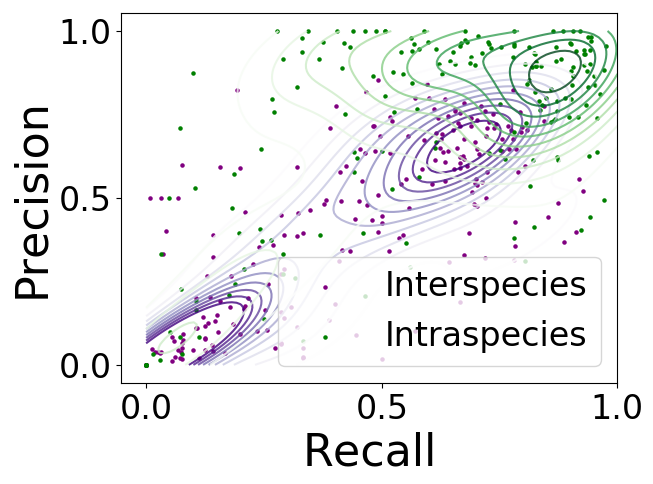


[Fig 1G stats: precision/recall]
  Interspecies:   n=239  mean P=0.387, mean R=0.402
  Intraspecies:   n=183  mean P=0.711, mean R=0.601


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

plt.style.use("default")

FONT1 = 24
FONT2 = 32
plt.rcParams.update({"font.size": FONT1})

RES_VH_PATH = "Fig1A-C/Interspecies_whole_structure_evaluation_addDDPP_bound_0.4_noFailed.txt"
RES_HH_PATH = "Fig1A-C/Intraspecies_whole_structure_evaluation_AFM_all.txt"
custom_palette = ["violet", "lime", "#2ecc71", "#f39c12"]

def load_vh_hh():
    """Apply only the NumRes≥20 filters."""
    res_vh = pd.read_csv(RES_VH_PATH, sep="\t")
    res_hh = pd.read_csv(RES_HH_PATH, sep="\t")

    res_vh = res_vh[(res_vh["NumResProt1"] >= 20) & (res_vh["NumResProt2"] >= 20)].copy()
    res_hh = res_hh[(res_hh["NumResProt1"] >= 20) & (res_hh["NumResProt2"] >= 20)].copy()

    print(f"[INFO] complexes used: interspecies={res_vh.shape[0]}, intraspecies={res_hh.shape[0]}")
    return res_vh, res_hh

res_VH, res_HH = load_vh_hh()
# ---------------------------------------------------------------------
# Fig. 1G – Precision/Recall density: interspecies vs intraspecies
# ---------------------------------------------------------------------
def plot_fig1g(res_vh, res_hh, out_path="/home/ll863/Benchmark_interface_prediction_scatter_VH_HH.svg"):
    pre_vh = res_vh[res_vh["Ires_Precision"] > -1]["Ires_Precision"].to_numpy()
    rec_vh = res_vh[res_vh["Ires_Recall"] > -1]["Ires_Recall"].to_numpy()

    pre_hh = res_hh[res_hh["Ires_Precision"] > -1]["Ires_Precision"].to_numpy()
    rec_hh = res_hh[res_hh["Ires_Recall"] > -1]["Ires_Recall"].to_numpy()

    fig, ax = plt.subplots()

    # Interspecies scatter + KDE
    ax.scatter(rec_vh, pre_vh, color="purple", s=5)
    kde_vh = gaussian_kde(np.vstack([rec_vh, pre_vh]))
    xi, yi = np.mgrid[0:1:100j, 0:1:100j]
    zi_vh = kde_vh(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)
    levels = np.linspace(0.5, 3, 10)
    ax.contour(xi, yi, zi_vh, cmap="Purples", levels=levels, alpha=0.8)

    # Intraspecies scatter + KDE
    ax.scatter(rec_hh, pre_hh, color="green", s=5)
    kde_hh = gaussian_kde(np.vstack([rec_hh, pre_hh]))
    zi_hh = kde_hh(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)
    ax.contour(xi, yi, zi_hh, cmap="Greens", levels=levels, alpha=0.8)

    ax.legend(["Interspecies", "Intraspecies"], fontsize=FONT1)
    ax.set_xlabel("Recall", fontsize=FONT2)
    ax.set_ylabel("Precision", fontsize=FONT2)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])

    fig.savefig(out_path, format="svg", bbox_inches="tight")
    plt.show()

    # Stats hidden in the panel
    print("\n[Fig 1G stats: precision/recall]")
    print(f"  Interspecies:   n={len(pre_vh)}  mean P={pre_vh.mean():.3f}, mean R={rec_vh.mean():.3f}")
    print(f"  Intraspecies:   n={len(pre_hh)}  mean P={pre_hh.mean():.3f}, mean R={rec_hh.mean():.3f}")

plot_fig1g(res_VH, res_HH, "Fig1G-H/Fig1G.svg")

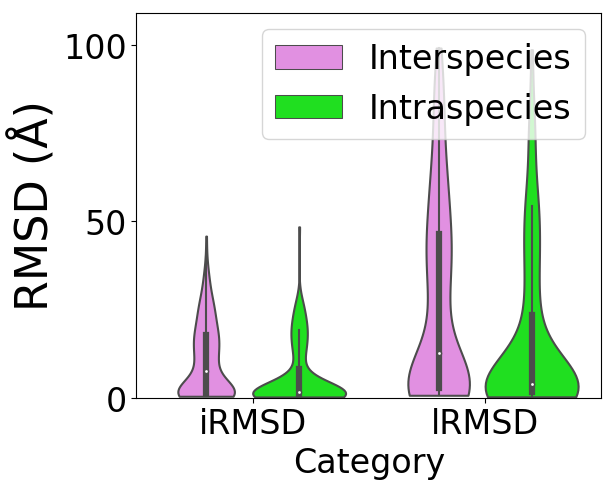


[Fig1H stats]
  iRMSD inter: n=210, mean=10.51, median=7.59
  iRMSD intra: n=146, mean=6.06, median=1.49
  lRMSD inter: n=207, mean=26.98, median=12.64
  lRMSD intra: n=146, mean=16.33, median=3.83


In [8]:
def plot_fig1h(res_VH: pd.DataFrame, res_HH: pd.DataFrame, out_path: str):
    """Fig 1H: iRMSD & lRMSD violins, VH vs HH."""

    res1 = res_VH[(res_VH.NumResProt1 >= 20) & (res_VH.NumResProt2 >= 20)].copy()
    res2 = res_HH[(res_HH.NumResProt1 >= 20) & (res_HH.NumResProt2 >= 20)].copy()

    iRMSD1 = res1[(res1.iRMSD_AFM > 0) & (res1.iRMSD_AFM < 50)].iRMSD_AFM.to_list()
    iRMSD2 = res2[(res2.iRMSD_AFM > 0) & (res2.iRMSD_AFM < 50)].iRMSD_AFM.to_list()
    lRMSD1 = res1[(res1.lRMSD_AFM > 0) & (res1.lRMSD_AFM < 100)].lRMSD_AFM.to_list()
    lRMSD2 = res2[(res2.lRMSD_AFM > 0) & (res2.lRMSD_AFM < 100)].lRMSD_AFM.to_list()

    dat = iRMSD1 + iRMSD2 + lRMSD1 + lRMSD2
    cat = (["iRMSD"] * len(iRMSD1 + iRMSD2) +
           ["lRMSD"] * len(lRMSD1 + lRMSD2))
    grp = (["Interspecies"] * len(iRMSD1) +
           ["Intraspecies"] * len(iRMSD2) +
           ["Interspecies"] * len(lRMSD1) +
           ["Intraspecies"] * len(lRMSD2))

    df = pd.DataFrame({"Category": cat, "Group": grp, "RMSD": dat})

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.violinplot(
        x="Category",
        y="RMSD",
        hue="Group",
        data=df,
        palette=custom_palette,
        cut=0,
        ax=ax,
    )

    y_max = max(dat) if dat else 0
    ax.set_ylim(0, y_max + 10)
    # keep your 50 Å tick spacing
    ax.set_yticks(range(0, int(y_max) + 10, 50))
    ax.legend(loc="best", fontsize=FONT1)
    ax.set_ylabel("RMSD (Å)", fontsize=FONT2)

    fig.savefig(out_path, format="svg", bbox_inches="tight")
    plt.show()

    # stats
    print("\n[Fig1H stats]")
    print(f"  iRMSD inter: n={len(iRMSD1)}, mean={np.mean(iRMSD1):.2f}, "
          f"median={np.median(iRMSD1):.2f}")
    print(f"  iRMSD intra: n={len(iRMSD2)}, mean={np.mean(iRMSD2):.2f}, "
          f"median={np.median(iRMSD2):.2f}")
    print(f"  lRMSD inter: n={len(lRMSD1)}, mean={np.mean(lRMSD1):.2f}, "
          f"median={np.median(lRMSD1):.2f}")
    print(f"  lRMSD intra: n={len(lRMSD2)}, mean={np.mean(lRMSD2):.2f}, "
          f"median={np.median(lRMSD2):.2f}")

plot_fig1h(res_VH, res_HH, "Fig1G-H/Fig1H.svg")

[INFO] complexes used: interspecies=41, intraspecies=20


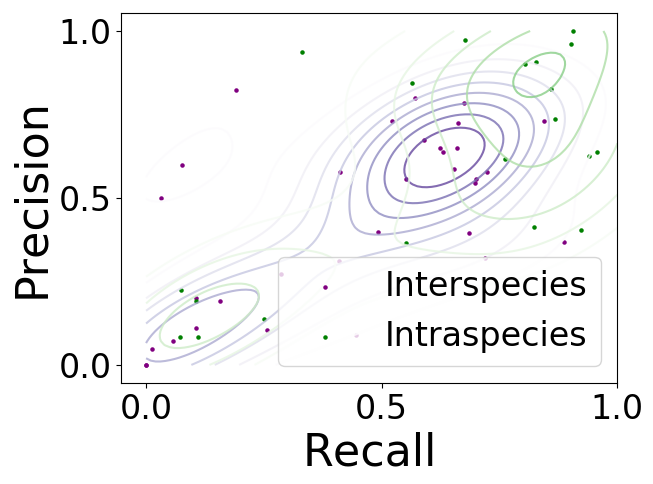


[Fig 1G stats: precision/recall]
  Interspecies:   n=33  mean P=0.442, mean R=0.437
  Intraspecies:   n=20  mean P=0.593, mean R=0.615


In [15]:
def load_vh_hh_unseen():
    """Apply only the NumRes≥20 filters."""
    res_vh = pd.read_csv(RES_VH_PATH, sep="\t")
    res_hh = pd.read_csv(RES_HH_PATH, sep="\t")

    res_vh = res_vh[(res_vh["NumResProt1"] >= 20) & (res_vh["NumResProt2"] >= 20) & res_vh.Date_after_train].copy()
    res_hh = res_hh[(res_hh["NumResProt1"] >= 20) & (res_hh["NumResProt2"] >= 20) & res_hh.Date_after_train].copy()

    print(f"[INFO] complexes used: interspecies={res_vh.shape[0]}, intraspecies={res_hh.shape[0]}")
    return res_vh, res_hh

res_VH, res_HH = load_vh_hh_unseen()

# ---------------------------------------------------------------------
# Fig. S1B – Precision/Recall density: interspecies vs intraspecies for unseen cases
# ---------------------------------------------------------------------
def plot_figs1b(res_vh, res_hh, out_path="FigS1b.svg"):
    pre_vh = res_vh[res_vh["Ires_Precision"] > -1]["Ires_Precision"].to_numpy()
    rec_vh = res_vh[res_vh["Ires_Recall"] > -1]["Ires_Recall"].to_numpy()

    pre_hh = res_hh[res_hh["Ires_Precision"] > -1]["Ires_Precision"].to_numpy()
    rec_hh = res_hh[res_hh["Ires_Recall"] > -1]["Ires_Recall"].to_numpy()

    fig, ax = plt.subplots()

    # Interspecies scatter + KDE
    ax.scatter(rec_vh, pre_vh, color="purple", s=5)
    kde_vh = gaussian_kde(np.vstack([rec_vh, pre_vh]))
    xi, yi = np.mgrid[0:1:100j, 0:1:100j]
    zi_vh = kde_vh(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)
    levels = np.linspace(0.5, 3, 10)
    ax.contour(xi, yi, zi_vh, cmap="Purples", levels=levels, alpha=0.8)

    # Intraspecies scatter + KDE
    ax.scatter(rec_hh, pre_hh, color="green", s=5)
    kde_hh = gaussian_kde(np.vstack([rec_hh, pre_hh]))
    zi_hh = kde_hh(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)
    ax.contour(xi, yi, zi_hh, cmap="Greens", levels=levels, alpha=0.8)

    ax.legend(["Interspecies", "Intraspecies"], fontsize=FONT1)
    ax.set_xlabel("Recall", fontsize=FONT2)
    ax.set_ylabel("Precision", fontsize=FONT2)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])

    fig.savefig(out_path, format="svg", bbox_inches="tight")
    plt.show()

    # Stats hidden in the panel
    print("\n[Fig 1G stats: precision/recall]")
    print(f"  Interspecies:   n={len(pre_vh)}  mean P={pre_vh.mean():.3f}, mean R={rec_vh.mean():.3f}")
    print(f"  Intraspecies:   n={len(pre_hh)}  mean P={pre_hh.mean():.3f}, mean R={rec_hh.mean():.3f}")


plot_figs1b(res_VH, res_HH, "FigS1B-C/FigS1B.svg")

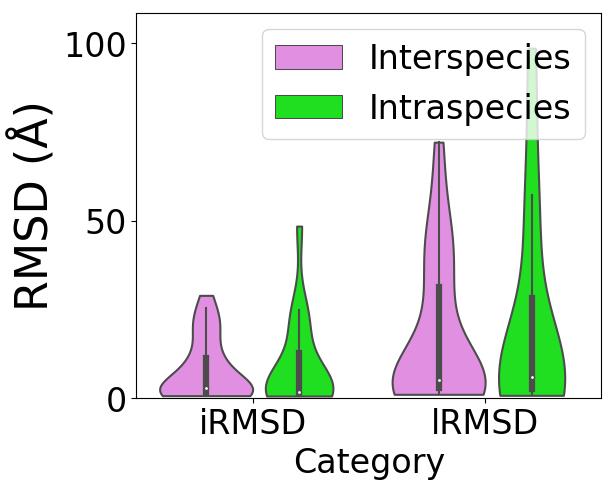


[Fig1H stats]
  iRMSD inter: n=30, mean=7.90, median=2.79
  iRMSD intra: n=19, mean=8.96, median=1.70
  lRMSD inter: n=30, mean=17.36, median=5.07
  lRMSD intra: n=19, mean=21.09, median=5.94


In [16]:
def plot_figs1c(res_VH: pd.DataFrame, res_HH: pd.DataFrame, out_path: str):
    """Fig S1C: iRMSD & lRMSD violins, VH vs HH."""

    res1 = res_VH[(res_VH.NumResProt1 >= 20) & (res_VH.NumResProt2 >= 20)].copy()
    res2 = res_HH[(res_HH.NumResProt1 >= 20) & (res_HH.NumResProt2 >= 20)].copy()

    iRMSD1 = res1[(res1.iRMSD_AFM > 0) & (res1.iRMSD_AFM < 50)].iRMSD_AFM.to_list()
    iRMSD2 = res2[(res2.iRMSD_AFM > 0) & (res2.iRMSD_AFM < 50)].iRMSD_AFM.to_list()
    lRMSD1 = res1[(res1.lRMSD_AFM > 0) & (res1.lRMSD_AFM < 100)].lRMSD_AFM.to_list()
    lRMSD2 = res2[(res2.lRMSD_AFM > 0) & (res2.lRMSD_AFM < 100)].lRMSD_AFM.to_list()

    dat = iRMSD1 + iRMSD2 + lRMSD1 + lRMSD2
    cat = (["iRMSD"] * len(iRMSD1 + iRMSD2) +
           ["lRMSD"] * len(lRMSD1 + lRMSD2))
    grp = (["Interspecies"] * len(iRMSD1) +
           ["Intraspecies"] * len(iRMSD2) +
           ["Interspecies"] * len(lRMSD1) +
           ["Intraspecies"] * len(lRMSD2))

    df = pd.DataFrame({"Category": cat, "Group": grp, "RMSD": dat})

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.violinplot(
        x="Category",
        y="RMSD",
        hue="Group",
        data=df,
        palette=custom_palette,
        cut=0,
        ax=ax,
    )

    y_max = max(dat) if dat else 0
    ax.set_ylim(0, y_max + 10)
    # keep your 50 Å tick spacing
    ax.set_yticks(range(0, int(y_max) + 10, 50))
    ax.legend(loc="best", fontsize=FONT1)
    ax.set_ylabel("RMSD (Å)", fontsize=FONT2)

    fig.savefig(out_path, format="svg", bbox_inches="tight")
    plt.show()

    # stats
    print("\n[Fig1H stats]")
    print(f"  iRMSD inter: n={len(iRMSD1)}, mean={np.mean(iRMSD1):.2f}, "
          f"median={np.median(iRMSD1):.2f}")
    print(f"  iRMSD intra: n={len(iRMSD2)}, mean={np.mean(iRMSD2):.2f}, "
          f"median={np.median(iRMSD2):.2f}")
    print(f"  lRMSD inter: n={len(lRMSD1)}, mean={np.mean(lRMSD1):.2f}, "
          f"median={np.median(lRMSD1):.2f}")
    print(f"  lRMSD intra: n={len(lRMSD2)}, mean={np.mean(lRMSD2):.2f}, "
          f"median={np.median(lRMSD2):.2f}")

plot_fig1h(res_VH, res_HH, "FigS1B-C/FigS1C.svg")